In [1]:
import pandas as pd

train_df = pd.read_csv('Train_Preprocessed_Data.csv')
test_df = pd.read_csv('Test_Preprocessed_Data.csv')

X_train = train_df.drop('Has_Mental_Health_Issue', axis=1)
y_train = train_df['Has_Mental_Health_Issue']

X_test = test_df.drop('Has_Mental_Health_Issue', axis=1)
y_test = test_df['Has_Mental_Health_Issue']

In [2]:
from sklearn.model_selection import train_test_split

X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

In [3]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    recall_score,
    precision_score,
    roc_auc_score,
    confusion_matrix
)

def evaluate_model(model, X_train, y_train, X_val, y_val):

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    val_pred = model.predict(X_val)

    results = {
        "train_f1": f1_score(y_train, train_pred),
        "val_f1": f1_score(y_val, val_pred),
        "val_recall": recall_score(y_val, val_pred),
        "val_precision": precision_score(y_val, val_pred),
        "val_accuracy": accuracy_score(y_val, val_pred)
    }

    return results

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

models = {
    "LogisticRegression": LogisticRegression(max_iter=1000),

    "DecisionTree_Gini": DecisionTreeClassifier(criterion="gini"),
    "DecisionTree_Entropy": DecisionTreeClassifier(criterion="entropy"),

    "RandomForest": RandomForestClassifier(n_estimators=200),

    "XGBoost": XGBClassifier(
        eval_metric='logloss',
        n_estimators=200,
        learning_rate=0.1,
        max_depth=6
    )
}

In [5]:
results = {}

for name, model in models.items():

    print(f"Training {name}...")

    res = evaluate_model(
        model,
        X_train_final,
        y_train_final,
        X_val,
        y_val
    )

    results[name] = res

Training LogisticRegression...
Training DecisionTree_Gini...
Training DecisionTree_Entropy...
Training RandomForest...
Training XGBoost...


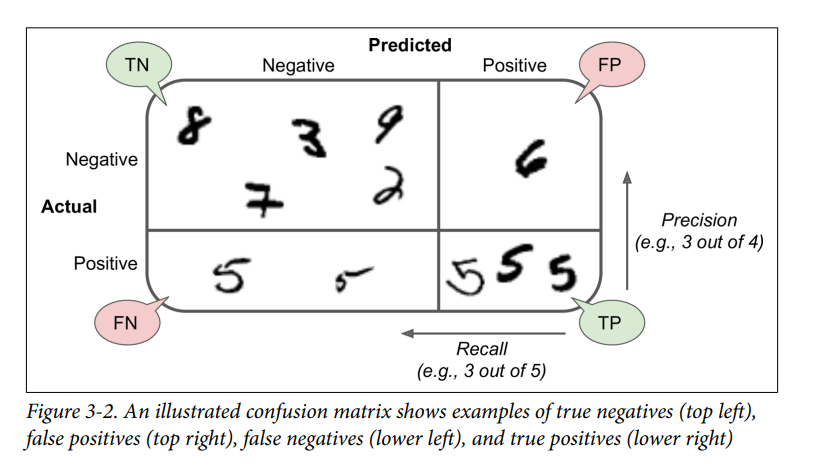

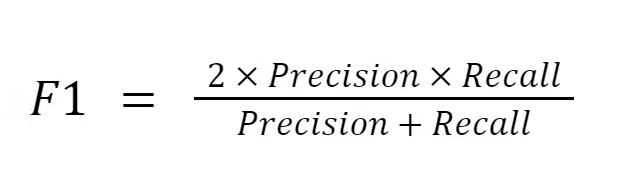

In [6]:
results_df = pd.DataFrame(results).T
results_df.sort_values(by="val_f1", ascending=False)

,train_f1,val_f1,val_recall,val_precision,val_accuracy
LogisticRegression,0.959214,0.959147,1.000000,0.921500,0.9215
RandomForest,1.000000,0.959147,1.000000,0.921500,0.9215
XGBoost,0.998510,0.958583,0.998372,0.921844,0.9205
DecisionTree_Entropy,1.000000,0.924579,0.924579,0.924579,0.8610
DecisionTree_Gini,1.000000,0.916415,0.907216,0.925803,0.8475


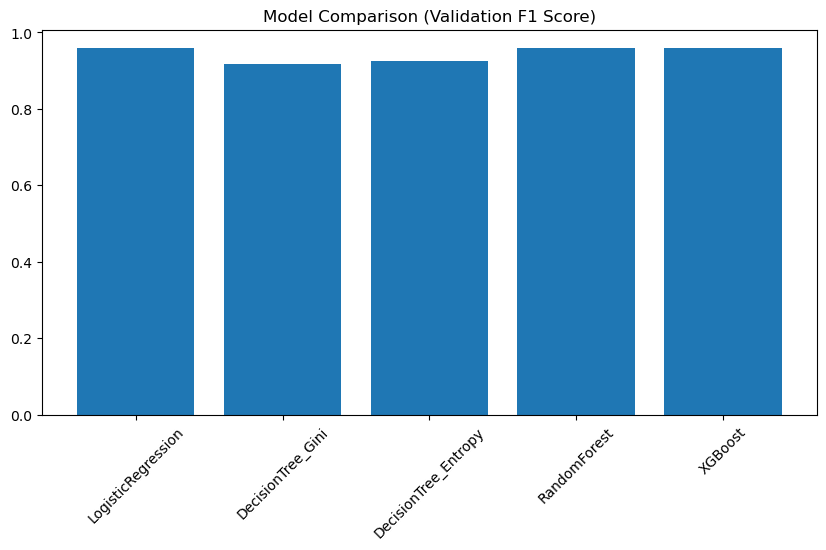

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(
    results_df.index,
    results_df["val_f1"]
)

plt.title("Model Comparison (Validation F1 Score)")
plt.xticks(rotation=45)
plt.show()

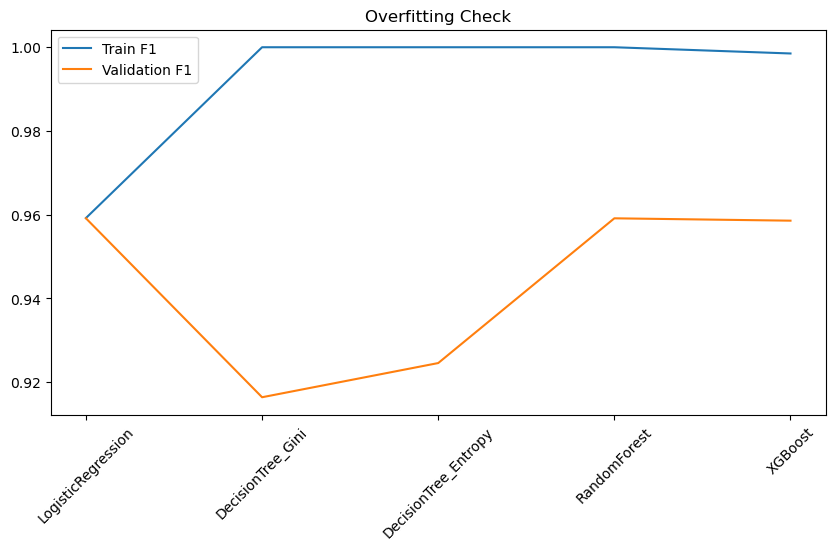

In [8]:
plt.figure(figsize=(10,5))

plt.plot(results_df.index, results_df["train_f1"], label="Train F1")
plt.plot(results_df.index, results_df["val_f1"], label="Validation F1")

plt.legend()
plt.xticks(rotation=45)
plt.title("Overfitting Check")
plt.show()

In [9]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, f1_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

In [10]:
rf = RandomForestClassifier(random_state=42)

rf_params = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=rf_params,
    scoring="f1",
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(X_train_final, y_train_final)


Fitting 3 folds for each of 216 candidates, totalling 648 fits


,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [None, 5, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [11]:
best_rf = grid_rf.best_estimator_

print(grid_rf.best_params_)

{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


In [12]:
xgb = XGBClassifier(
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42
)

xgb_params = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0]
}

grid_xgb = GridSearchCV(
    estimator=xgb,
    param_grid=xgb_params,
    scoring="f1",
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_xgb.fit(X_train_final, y_train_final)


Fitting 3 folds for each of 243 candidates, totalling 729 fits


c:\Users\hadyh\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [14:19:38] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,estimator,"XGBClassifier...ree=None, ...)"
,param_grid,"{'colsample_bytree': [0.7, 0.8, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200, ...], ...}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'binary:logistic'


In [13]:
best_xgb = grid_xgb.best_estimator_

print(grid_xgb.best_params_)

{'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 100, 'subsample': 0.8}


In [14]:
def plot_learning_curve(model, X, y, title):

    train_sizes, train_scores, val_scores = learning_curve(
        model,
        X,
        y,
        cv=3,
        scoring="f1",
        n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 100)
    )

    train_mean = np.mean(train_scores, axis=1)
    val_mean = np.mean(val_scores, axis=1)

    plt.plot(train_sizes, train_mean, label="Train F1")
    plt.plot(train_sizes, val_mean, label="Validation F1")

    plt.title(title)
    plt.xlabel("Training Size")
    plt.ylabel("F1 Score")
    plt.legend()
    plt.show()

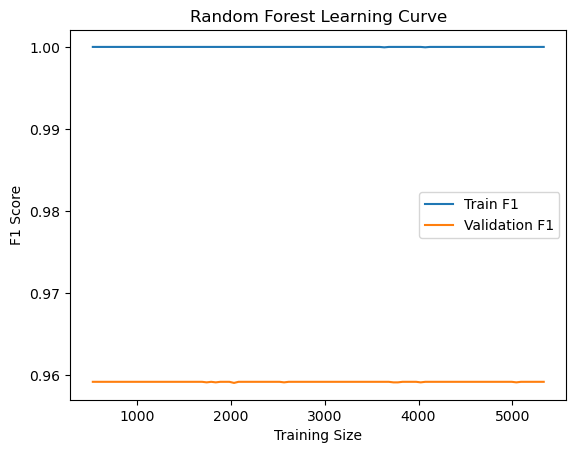

In [15]:
plot_learning_curve(best_rf, X_train_final, y_train_final, "Random Forest Learning Curve")


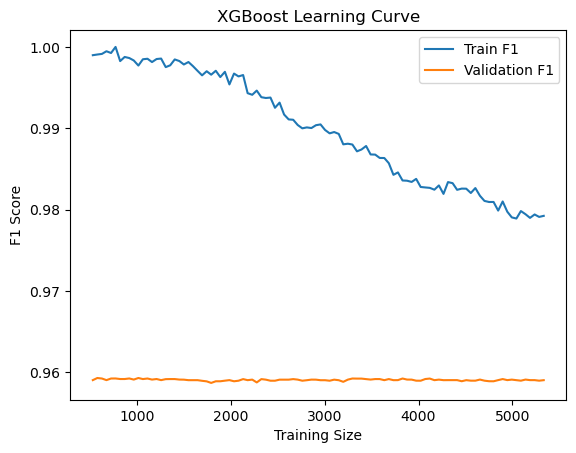

In [16]:
plot_learning_curve(best_xgb, X_train_final, y_train_final, "XGBoost Learning Curve")


In [17]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    colsample_bytree=0.8,
    learning_rate=0.05,
    max_depth=5,
    n_estimators=300,

    reg_lambda=5,
    reg_alpha=0.5,
    gamma=0.2,

    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(
    X_train_final, y_train_final,
    eval_set=[(X_val, y_val)],
    verbose=False
)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


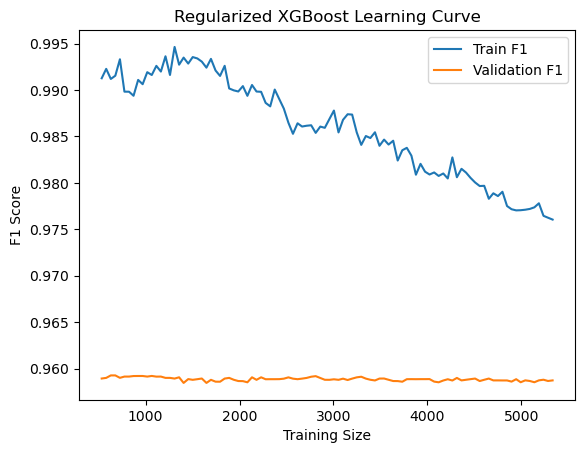

In [18]:
plot_learning_curve(
    xgb_model,
    X_train_final,
    y_train_final,
    "Regularized XGBoost Learning Curve"
)


In [19]:
# ── Validation Metrics for Final XGB Model ──
val_pred = xgb_model.predict(X_val)

print("=== Validation Metrics ===")
print(f"Accuracy : {accuracy_score(y_val, val_pred):.4f}")
print(f"F1 Score : {f1_score(y_val, val_pred):.4f}")
print(f"Recall   : {recall_score(y_val, val_pred):.4f}")
print(f"Precision: {precision_score(y_val, val_pred):.4f}")
print(f"AUC-ROC  : {roc_auc_score(y_val, xgb_model.predict_proba(X_val)[:,1]):.4f}")


=== Validation Metrics ===
Accuracy : 0.9200
F1 Score : 0.9583
Recall   : 0.9984
Precision: 0.9214
AUC-ROC  : 0.5968


In [21]:
# ── Test Metrics for Final XGB Model ──
test_pred = xgb_model.predict(X_test)

print("=== Test Metrics ===")
print(f"Accuracy : {accuracy_score(y_test, test_pred):.4f}")
print(f"F1 Score : {f1_score(y_test, test_pred):.4f}")
print(f"Recall   : {recall_score(y_test, test_pred):.4f}")
print(f"Precision: {precision_score(y_test, test_pred):.4f}")
print(f"AUC-ROC  : {roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:,1]):.4f}")

print("\n=== Confusion Matrix (Test) ===")
print(confusion_matrix(y_test, test_pred))

from sklearn.metrics import classification_report
print("\n=== Classification Report (Test) ===")
print(classification_report(y_test, test_pred))


=== Test Metrics ===
Accuracy : 0.9338
F1 Score : 0.9653
Recall   : 0.9997
Precision: 0.9332
AUC-ROC  : 0.9224

=== Confusion Matrix (Test) ===
[[ 125  659]
 [   3 9213]]

=== Classification Report (Test) ===
              precision    recall  f1-score   support

           0       0.98      0.16      0.27       784
           1       0.93      1.00      0.97      9216

    accuracy                           0.93     10000
   macro avg       0.95      0.58      0.62     10000
weighted avg       0.94      0.93      0.91     10000

